<a href="https://colab.research.google.com/github/andreasantalla/ASE-GIS/blob/main/sep_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [sep 10] Dive into thematic/choloropleth maps

 the key skill you will learn--we color code polygons (or lines or points) with levels of a variable, say green for low covid19, yellow for moderate, and red for high


REFS (also good for self study):

https://geographicdata.science/book/notebooks/05_choropleth.html
[like a textbook, good stuff like most by darribas (little wordy tho)]

https://geopandas.org/en/stable/gallery/choropleths.html

https://geopandas.org/en/stable/gallery/choro_legends.html

first, mapping var from gis datafile--rarely lucky and have the variable we want to map already in the shapefile

## **Load Packages**

In [80]:
## ===== Imports =====
import os, zipfile
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from shapely.geometry import Point
import mapclassify
import numpy as np

In [81]:
#!python --version
gpd.__version__

'1.1.4'

##  **Load 2020-vintage Philly tracts**

<Axes: >

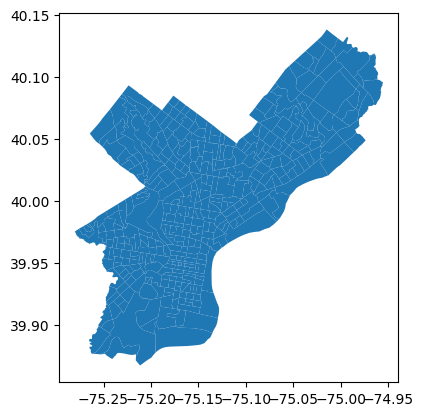

In [82]:
## ===== Load 2020-vintage Philly tracts (matches ACS 2022 5-year boundaries) =====
!wget -q -O phl_tracts_2020.zip "https://www2.census.gov/geo/tiger/TIGER2020/TRACT/tl_2020_42_tract.zip"
zipfile.ZipFile('phl_tracts_2020.zip', 'r').extractall()

pa_tracts = gpd.read_file('tl_2020_42_tract.shp')
phT = pa_tracts[pa_tracts['COUNTYFP'] == '101'][['GEOID', 'NAME', 'geometry']].copy()
phT['GEOID'] = phT['GEOID'].astype(str)
phT.plot()  # sanity check: should look like Philadelphia

## **Reusable functions**

In [83]:
## ===== Reusable ACS pull function (from GitHub instead of Census API) =====
def pull_acs_table_from_github(url, variables, fname):
    """Downloads a pre-saved ACS JSON from GitHub, returns a tidy dataframe with GEOID."""
    os.system(f'wget -q -O {fname} "{url}"')

    df = pd.read_json(fname)
    df.columns = df.iloc[0]
    df = df[1:].reset_index(drop=True)
    for col in variables:
        df[col] = pd.to_numeric(df[col])
    df['GEOID'] = df['state'] + df['county'] + df['tract']
    return df

In [84]:
## ===== Reusable mapping function =====
def plot_lep_choropleth(gdf, column, title, legend_title, no_data_label, point_lon, point_lat):
    """Plots a choropleth with a red point overlay, gray hatching for missing data, and dual legends."""
    gdf_4326 = gdf.to_crs(epsg=4326)
    valid = gdf_4326.dropna(subset=[column])
    missing = gdf_4326[gdf_4326[column].isna()]

    print(f"Missing: {len(missing)} of {len(gdf_4326)} tracts")

    fig, ax = plt.subplots(1, figsize=(6, 10))

    missing.plot(ax=ax, color='lightgray', edgecolor='black', linewidth=0.5, hatch='///')
    valid.plot(column=column, cmap='RdYlGn_r', scheme='natural_breaks', k=5,
               legend=True, ax=ax, edgecolor='black', linewidth=0.5)

    choropleth_legend = ax.get_legend()
    choropleth_legend.set_title(legend_title)
    choropleth_legend.set_bbox_to_anchor((1.05, 1))

    ax.scatter(point_lon, point_lat, marker='o', color='red', s=60, zorder=5)
    ax.set_title(title)
    ax.axis('off')

    ax.add_artist(choropleth_legend)
    point = Line2D([0], [0], label='Comunidad Garces', marker='o', markersize=8,
                   markeredgecolor='r', markerfacecolor='r', linestyle='')
    no_data = Line2D([0], [0], label=no_data_label, marker='s', markersize=8,
                      markerfacecolor='lightgray', markeredgecolor='black', linestyle='')
    ax.legend(handles=[point, no_data], loc='lower right')

    plt.show()

In [85]:
## ===== Comunidad Garces location =====
garces_lat, garces_lon = 39.9249, -75.1601
garces_point = gpd.GeoSeries([Point(garces_lon, garces_lat)], crs='EPSG:4326')
garces_point_proj = garces_point.to_crs(epsg=2272)   # PA State Plane, feet
buffer_1mi = garces_point_proj.buffer(5280).to_crs(epsg=4326)  # 1 mile

## **Pull the two ACS tables from GitHub**

In [86]:
acs_lep_hh = pull_acs_table_from_github(
    url="https://raw.githubusercontent.com/andreasantalla/ASE-GIS/refs/heads/main/acs5_householdLEP.json",
    variables=['C16002_001E', 'C16002_003E'],
    fname="acs_lep_hh.json"
)
acs_lep_hh['pct_lep_spanish_hh'] = 100 * acs_lep_hh['C16002_003E'] / acs_lep_hh['C16002_001E']

acs_income = pull_acs_table_from_github(
    url="https://raw.githubusercontent.com/andreasantalla/ASE-GIS/refs/heads/main/acs5_income.json",
    variables=['B19013_001E'],
    fname="acs_income.json"
)
acs_income = acs_income.rename(columns={'B19013_001E': 'median_hh_income'})

****
## **Map 1: Household-Level LEP with buffer, annotation, zoom**
Linguistically-isolated households = Spanish-speaking households that are "Limited English speaking household" (no one 14+ speaks English "very well")

<Axes: >

<Axes: >

<Axes: >

Text(0.02, 0.02, 'Within 1 mile: 29 tracts,\navg 7.7% LEP households')

(-75.2051, -75.1151)

(39.8799, 39.9699)

Text(0.5, 1.0, 'Linguistically Isolated Spanish-Speaking Households\nNear Comunidad Garces (1-Mile Service Radius)')

(np.float64(-75.2051),
 np.float64(-75.1151),
 np.float64(39.8799),
 np.float64(39.9699))

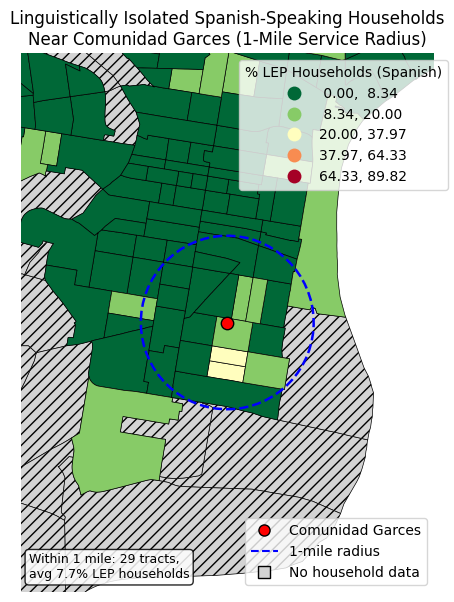

In [98]:
phlLEP_hh = phT.merge(acs_lep_hh[['GEOID', 'pct_lep_spanish_hh']], on='GEOID', how='left')
phlLEP_hh_4326 = phlLEP_hh.to_crs(epsg=4326)

valid = phlLEP_hh_4326.dropna(subset=['pct_lep_spanish_hh'])
missing = phlLEP_hh_4326[phlLEP_hh_4326['pct_lep_spanish_hh'].isna()]

fig, ax = plt.subplots(1, figsize=(9, 7))

missing.plot(ax=ax, color='lightgray', edgecolor='black', linewidth=0.5, hatch='///')
valid.plot(column='pct_lep_spanish_hh', cmap='RdYlGn_r', scheme='natural_breaks', k=5,
           legend=True, ax=ax, edgecolor='black', linewidth=0.5)

choropleth_legend = ax.get_legend()
choropleth_legend.set_title('% LEP Households (Spanish)')
choropleth_legend.set_bbox_to_anchor((1.05, 1))

buffer_1mi.plot(ax=ax, color='none', edgecolor='blue', linewidth=1.8, linestyle='--', zorder=4)
ax.scatter(garces_lon, garces_lat, marker='o', color='red', s=80, zorder=5, edgecolor='black')

tracts_in_buffer = valid[valid.geometry.intersects(buffer_1mi.iloc[0])]
avg_lep_nearby = tracts_in_buffer['pct_lep_spanish_hh'].mean()
ax.text(0.02, 0.02,
        f"Within 1 mile: {len(tracts_in_buffer)} tracts,\navg {avg_lep_nearby:.1f}% LEP households",
        transform=ax.transAxes, fontsize=9, va='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

ax.set_xlim(garces_lon - 0.045, garces_lon + 0.045)
ax.set_ylim(garces_lat - 0.045, garces_lat + 0.045)

ax.set_title('Linguistically Isolated Spanish-Speaking Households\nNear Comunidad Garces (1-Mile Service Radius)')
ax.axis('off')

ax.add_artist(choropleth_legend)
point = Line2D([0], [0], label='Comunidad Garces', marker='o', markersize=8,
               markeredgecolor='black', markerfacecolor='red', linestyle='')
radius = Line2D([0], [0], label='1-mile radius', color='blue', linestyle='--')
no_data = Line2D([0], [0], label='No household data', marker='s', markersize=8,
                  markerfacecolor='lightgray', markeredgecolor='black', linestyle='')
ax.legend(handles=[point, radius, no_data], loc='lower right')

plt.savefig('lep_map.png', bbox_inches='tight', dpi=150)
plt.show()

****
## **Map 2: Bivariate map — Household LEP x Median Household Income**
LEP threshold — DOJ/HHS Title VI "Safe Harbor" provision
Federal guidance under Title VI (following Executive Order 13166) sets the recognized threshold at written translation being required for each eligible LEP language group that constitutes five percent or 1,000 people, whichever is less, of the population eligible to be served. In practice, for a tract-level map, this means: 5% household LEP rate is the recognized "significant population" trigger — below 5% is not officially recognized as requiring language access accommodation, at or above 5% is.
(U.S. Department of Health and Human Services)

Income threshold — HUD Area Median Income (AMI) brackets
For the Philadelphia-Camden-Wilmington, PA-NJ-DE-MD MSA, FY2024 HUD income limits for a 4-person household are: 30% LIMITS 34,400; VERY LOW INCOME (50%) 57,350; 60% LIMITS 68,820; LOW INCOME (80%) 91,750. The standard three-tier HUD system is extremely low-income (30% AMI), very low-income (50% AMI), and low-income (80% AMI).
(HUD)

Since median household income (not adjusted for household size) is what I'm pulling from ACS, the cleanest way to bucket tracts is against the 4-person benchmark, with a clear caveat noted in your write-up that HUD's brackets are technically household-size-adjusted and yours is a simplification.

<Axes: >

<Axes: >

<Axes: >

(-75.2051, -75.1151)

(39.8799, 39.9699)

...

[]

[]

Text(0.5, 0, '<50% | 50-80% | >80%\nAMI')

Text(0, 0.5, 'LEP\n<5% | 5-15% | >15%')

Text(0.5, 1.0, 'Bivariate Key')

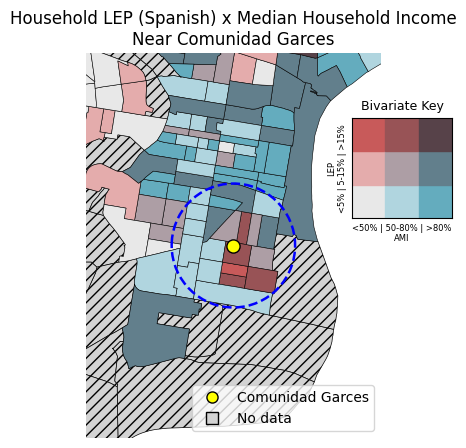

In [114]:
biv = phT.merge(acs_lep_hh[['GEOID', 'pct_lep_spanish_hh']], on='GEOID', how='left')
biv = biv.merge(acs_income[['GEOID', 'median_hh_income']], on='GEOID', how='left')

biv_4326 = biv.to_crs(epsg=4326)
biv_valid = biv_4326.dropna(subset=['pct_lep_spanish_hh', 'median_hh_income']).copy()
biv_missing = biv_4326[biv_4326['pct_lep_spanish_hh'].isna() | biv_4326['median_hh_income'].isna()]

## ===== Fixed-threshold bivariate classification (HUD AMI x Title VI LEP Safe Harbor) =====

# LEP classes based on Title VI Safe Harbor threshold (5%)
# 0 = below threshold, 1 = at/above threshold but under a higher "high need" marker, 2 = well above threshold
def classify_lep(pct):
    if pct < 5:
        return 0        # below Title VI Safe Harbor threshold
    elif pct < 15:
        return 1        # meets/exceeds Safe Harbor threshold
    else:
        return 2         # substantially exceeds threshold (elevated need)

biv_valid['lep_class'] = biv_valid['pct_lep_spanish_hh'].apply(classify_lep)

# Income classes based on HUD FY2024 AMI limits for Philadelphia MSA, 4-person household
# 30% AMI = $34,400 (Extremely Low Income)
# 50% AMI = $57,350 (Very Low Income)
# 80% AMI = $91,750 (Low Income)
def classify_income(income):
    if income < 57350:
        return 0        # at/below Very Low Income (50% AMI)
    elif income < 91750:
        return 1        # Low Income band (50-80% AMI)
    else:
        return 2         # above Low Income threshold (80%+ AMI)

biv_valid['income_class'] = biv_valid['median_hh_income'].apply(classify_income)
bivariate_colors = {
    (0, 0): '#e8e8e8', (1, 0): '#b0d5df', (2, 0): '#64acbe',   # low LEP row
    (0, 1): '#e4acac', (1, 1): '#ad9ea5', (2, 1): '#627f8c',   # mid LEP row
    (0, 2): '#c85a5a', (1, 2): '#985356', (2, 2): '#574249',   # high LEP row
}

biv_valid['biv_color'] = biv_valid.apply(
    lambda row: bivariate_colors[(row['income_class'], row['lep_class'])], axis=1
)

fig, ax = plt.subplots(1, figsize=(5, 5))

biv_missing.plot(ax=ax, color='lightgray', edgecolor='black', linewidth=0.5, hatch='///')
biv_valid.plot(ax=ax, color=biv_valid['biv_color'], edgecolor='black', linewidth=0.4)

buffer_1mi.plot(ax=ax, color='none', edgecolor='blue', linewidth=1.8, linestyle='--', zorder=4)
ax.scatter(garces_lon, garces_lat, marker='o', color='yellow', s=90, zorder=5, edgecolor='black')

ax.set_xlim(garces_lon - 0.045, garces_lon + 0.045)
ax.set_ylim(garces_lat - 0.045, garces_lat + 0.045)

ax.set_title('Household LEP (Spanish) x Median Household Income\nNear Comunidad Garces')
ax.axis('off')

point = Line2D([0], [0], label='Comunidad Garces', marker='o', markersize=8,
               markeredgecolor='black', markerfacecolor='yellow', linestyle='')
no_data = Line2D([0], [0], label='No data', marker='s', markersize=8,
                  markerfacecolor='lightgray', markeredgecolor='black', linestyle='')
ax.legend(handles=[point, no_data], loc='lower right')

legend_ax = fig.add_axes([0.75, 0.55, 0.20, 0.20])
for income_c in range(3):
    for lep_c in range(3):
        legend_ax.add_patch(plt.Rectangle((income_c, lep_c), 1, 1,
                                           color=bivariate_colors[(income_c, lep_c)]))
legend_ax.set_xlim(0, 3)
legend_ax.set_ylim(0, 3)
legend_ax.set_xticks([])
legend_ax.set_yticks([])
legend_ax.set_xlabel('<50% | 50-80% | >80%\nAMI', fontsize=6)
legend_ax.set_ylabel('LEP\n<5% | 5-15% | >15%', fontsize=6)
legend_ax.set_title('Bivariate Key', fontsize=9)

plt.show()

## **References**
1. https://claude.ai
2. https://opendataphilly.org/datasets/census-tracts/
3. https://opendataphilly.org/datasets/city-limits/
4. https://data.census.gov/table/ACSDT5Y2022.C16002
5. https://data.census.gov/table/ACSDT5Y2022.B19013